# UC4 — Inteligencia Conversacional: Feature Engineering

**Author:** Fernando Haro (fh)  
**Use Case:** UC4 — Extracción de intents, sentimiento y cruces con comportamiento transaccional  
**Project:** datamoles — Datathon DSC x Hey 2026  
**Output:** `feat_uc4_turns.parquet`, `feat_uc4_convs.parquet`, `feat_uc4_users.parquet`, `feat_uc4_embeddings.npy`, `feat_uc4_cross_summary.json`

## 0. Setup

In [1]:
# Author: Fernando Haro | UC4 — Inteligencia Conversacional: Feature Engineering
import pandas as pd
import numpy as np
from pathlib import Path
import unicodedata
import warnings
warnings.filterwarnings('ignore')

CUTOFF_DATE      = pd.Timestamp("2025-10-31")
EMBED_MODEL      = "paraphrase-multilingual-MiniLM-L12-v2"
EMBED_BATCH_SIZE = 64

BASE_TXN  = Path("/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones")
BASE_CONV = Path("/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_dataset_conversaciones 1/dataset_conversaciones")
OUTPUT_DIR = Path("/Users/diegodq/Documents/dev/datamoles/Datathon-2026/outputs/features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_TXN  exists: {BASE_TXN.exists()}")
print(f"BASE_CONV exists: {BASE_CONV.exists()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

BASE_TXN  exists: True
BASE_CONV exists: True
OUTPUT_DIR: /Users/diegodq/Documents/dev/datamoles/Datathon-2026/outputs/features


## 1. Carga y limpieza de conversaciones

Pasos clave:
- Eliminar 18 duplicados conocidos antes de cualquier procesamiento
- Parsear `date` con `format='mixed'` por los nanosegundos
- Filtrar a `CUTOFF_DATE` para alinear con el resto de features

In [2]:
%%time
df_convs = pd.read_parquet(BASE_CONV / "dataset_50k_anonymized.parquet")
print(f"Shape original: {df_convs.shape}")
print(df_convs.dtypes)
df_convs.head(3)

Shape original: (49999, 6)
input             str
output            str
date              str
conv_id           str
user_id           str
channel_source    str
dtype: object
CPU times: user 45.5 ms, sys: 12.4 ms, total: 57.9 ms
Wall time: 53.2 ms


,input,output,date,conv_id,user_id,channel_source
0,"Me enteré de una promo ""Supercashback Pagos Gu...",Claro que puedo ayudarte! Para participar en l...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
1,La tarjeta de crédito Hey Negocios es diferent...,Claro! La Tarjeta de Crédito Hey Negocios es d...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
2,"Entiendo, gracias",¡De nada! Me alegra haber podido ayudarte. Si ...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1


In [3]:
# Parsear date con format='mixed' por nanosegundos en algunas filas
df_convs['date'] = pd.to_datetime(df_convs['date'], format='mixed')

# channel_source ya viene como string '1'/'2' — dejarlo así
df_convs['channel_source'] = df_convs['channel_source'].astype(str)

# Deduplicar — hay 18 filas duplicadas conocidas
shape_before = df_convs.shape
df_convs = df_convs.drop_duplicates()
shape_after = df_convs.shape
print(f"Antes de dedup: {shape_before}  →  Después: {shape_after}  (eliminadas: {shape_before[0] - shape_after[0]})")

# Filtrar a CUTOFF_DATE para alinearnos con el resto del pipeline
df_convs = df_convs[df_convs['date'] <= CUTOFF_DATE].copy()
print(f"Shape final (≤ {CUTOFF_DATE.date()}): {df_convs.shape}")

Antes de dedup: (49999, 6)  →  Después: (49981, 6)  (eliminadas: 18)
Shape final (≤ 2025-10-31): (46136, 6)


## 2. Normalización de texto

Eliminamos `\ufffd` y caracteres no-ASCII con NFKD + encode/decode antes de cualquier procesamiento NLP.  
Agregamos features básicas de superficie del texto.

In [4]:
def normalize_text(text):
    """Normaliza a ASCII lowercase, elimina \ufffd y caracteres basura."""
    if pd.isna(text):
        return ""
    text = unicodedata.normalize('NFKD', str(text))
    text = text.encode('ascii', 'ignore').decode('ascii')  # elimina \ufffd y non-ascii
    return text.lower().strip()

df_convs['input_clean'] = df_convs['input'].apply(normalize_text)

# Features de superficie
df_convs['feat_input_len_chars'] = df_convs['input_clean'].str.len()
df_convs['feat_input_len_words'] = df_convs['input_clean'].str.split().str.len()
df_convs['feat_is_voz']          = df_convs['channel_source'] == "2"  # 2 = voz, 1 = texto

print(f"input_clean nulos: {df_convs['input_clean'].isna().sum()}")
print(f"input_clean vacíos: {(df_convs['input_clean'] == '').sum()}")
df_convs[['input_clean', 'feat_input_len_chars', 'feat_input_len_words', 'feat_is_voz']].head(5)

input_clean nulos: 0
input_clean vacíos: 7


,input_clean,feat_input_len_chars,feat_input_len_words,feat_is_voz
0,"me entere de una promo ""supercashback pagos gu...",157,26,False
1,la tarjeta de credito hey negocios es diferent...,65,12,False
2,"entiendo, gracias",17,2,False
3,hola,4,1,False
4,verificacion de cuenta,22,3,False


## 3. Clasificación de intents (rule-based baseline)

Taxonomía de 8 intents basada en keywords. Este baseline rule-based nos da una señal interpretable  
que podemos comparar contra el modelo de embeddings en pasos posteriores.

In [5]:
INTENT_RULES = {
    'consulta_saldo':       ['saldo', 'cuanto tengo', 'disponible', 'balance', 'cuenta'],
    'problema_transaccion': ['rechazo', 'no me paso', 'no se hizo', 'no proceso', 'fallo', 'error pago'],
    'reporte_fraude':       ['fraude', 'no reconozco', 'desconozco', 'cargo extrano', 'robo', 'no fui yo'],
    'pregunta_beneficios':  ['cashback', 'hey pro', 'beneficios', 'recompensa', 'puntos', 'promocion'],
    'solicitud_producto':   ['tarjeta', 'credito', 'prestamo', 'inversion', 'seguro', 'cuenta', 'solicitar'],
    'soporte_tecnico':      ['no funciona', 'error', 'app', 'no carga', 'falla', 'problema'],
    'consulta_movimientos': ['movimiento', 'transaccion', 'compra', 'cargo', 'historial', 'estado de cuenta'],
    'otro':                 []  # catch-all
}

def classify_intent(text: str) -> str:
    """Retorna el primer intent cuyas keywords aparecen en el texto, o 'otro' si ninguna."""
    for intent, keywords in INTENT_RULES.items():
        if intent == 'otro':
            continue
        if any(kw in text for kw in keywords):
            return intent
    return 'otro'

df_convs['feat_intent_baseline'] = df_convs['input_clean'].apply(classify_intent)

print("Distribución de intents (baseline rule-based):")
print(df_convs['feat_intent_baseline'].value_counts())

Distribución de intents (baseline rule-based):
feat_intent_baseline
otro                    25761
solicitud_producto      11487
consulta_saldo           4638
consulta_movimientos     1792
soporte_tecnico          1275
pregunta_beneficios       787
reporte_fraude            350
problema_transaccion       46
Name: count, dtype: int64


## 4. Embeddings (sentence-transformers)

Usamos `paraphrase-multilingual-MiniLM-L12-v2` para embeber cada turno de conversación.  
El modelo MiniLM-L12-v2 produce embeddings de **384 dimensiones**.  
En M3 16GB esto corre en CPU sin problema para 50k textos cortos.

Guardamos el array numpy por separado (no en el parquet) para evitar archivos gigantes.

In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(EMBED_MODEL)
print(f"Modelo cargado: {EMBED_MODEL}")
print(f"Dimensiones de embedding: {model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8950.75it/s]

Modelo cargado: paraphrase-multilingual-MiniLM-L12-v2
Dimensiones de embedding: 384


In [7]:
%%time
# Este es el paso más lento del notebook — ~2-5 min en M3 para ~50k textos
texts = df_convs['input_clean'].tolist()
embeddings = model.encode(
    texts,
    batch_size=EMBED_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"Embeddings shape: {embeddings.shape}")

Batches:   0%|          | 0/721 [00:00<?, ?it/s]

Batches:   0%|          | 1/721 [00:00<05:34,  2.15it/s]

Batches:   0%|          | 2/721 [00:00<03:40,  3.25it/s]

Batches:   0%|          | 3/721 [00:00<02:42,  4.40it/s]

Batches:   1%|          | 4/721 [00:00<02:12,  5.39it/s]

...

Batches:  96%|█████████▌| 691/721 [00:22<00:00, 78.67it/s]

Batches:  97%|█████████▋| 702/721 [00:22<00:00, 85.32it/s]

Batches:  99%|█████████▉| 713/721 [00:22<00:00, 91.83it/s]

Batches: 100%|██████████| 721/721 [00:22<00:00, 31.93it/s]

Embeddings shape: (46136, 384)
CPU times: user 7.04 s, sys: 1.64 s, total: 8.68 s
Wall time: 22.6 s


In [8]:
# Guardar embeddings en disco como numpy array (NO en el parquet — serían ~75MB extra)
np.save(OUTPUT_DIR / "feat_uc4_embeddings.npy", embeddings)
print(f"✅ Embeddings shape: {embeddings.shape}")
print(f"   Guardado en: {OUTPUT_DIR / 'feat_uc4_embeddings.npy'}")

# Guardar también el índice (posición en df_convs) para reconstruir la alineación
np.save(OUTPUT_DIR / "feat_uc4_embeddings_index.npy", df_convs.index.values)
print(f"✅ Índice de alineación guardado.")

✅ Embeddings shape: (46136, 384)
   Guardado en: /Users/diegodq/Documents/dev/datamoles/Datathon-2026/outputs/features/feat_uc4_embeddings.npy
✅ Índice de alineación guardado.


## 5. Features a nivel turno (`feat_uc4_turns.parquet`)

Un registro por turno/mensaje de usuario. Incluye features de texto, intent y temporales.

In [9]:
df_turns = df_convs[['conv_id', 'user_id', 'date']].copy()

# Features de texto y canal
df_turns['feat_is_voz']             = df_convs['feat_is_voz']
df_turns['feat_input_len_chars']    = df_convs['feat_input_len_chars']
df_turns['feat_input_len_words']    = df_convs['feat_input_len_words']
df_turns['feat_intent_baseline']    = df_convs['feat_intent_baseline']

# Features temporales
df_turns['feat_hora_dia']           = df_convs['date'].dt.hour
df_turns['feat_dia_semana']         = df_convs['date'].dt.dayofweek  # 0=lunes, 6=domingo

# Keyword flags — señales de alto valor para los cruces de sección 8
ic = df_convs['input_clean']
df_turns['feat_has_kw_fraude']    = ic.str.contains('fraude|no reconozco|desconozco', regex=True, na=False)
df_turns['feat_has_kw_rechazo']   = ic.str.contains('rechazo|no me paso|no proceso', regex=True, na=False)
df_turns['feat_has_kw_cashback']  = ic.str.contains('cashback|hey pro|beneficios', regex=True, na=False)
df_turns['feat_has_kw_credito']   = ic.str.contains('credito|tarjeta|prestamo', regex=True, na=False)
df_turns['feat_has_kw_inversion'] = ic.str.contains('inversion|rendimiento|ahorro', regex=True, na=False)

df_turns.to_parquet(OUTPUT_DIR / "feat_uc4_turns.parquet", index=False)
print(f"✅ feat_uc4_turns.parquet: {df_turns.shape}")
df_turns.head(3)

✅ feat_uc4_turns.parquet: (46136, 14)


,conv_id,user_id,date,feat_is_voz,feat_input_len_chars,feat_input_len_words,feat_intent_baseline,feat_hora_dia,feat_dia_semana,feat_has_kw_fraude,feat_has_kw_rechazo,feat_has_kw_cashback,feat_has_kw_credito,feat_has_kw_inversion
0,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,2025-08-17,False,157,26,pregunta_beneficios,0,6,False,False,True,False,False
1,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,2025-08-17,False,65,12,solicitud_producto,0,6,False,False,False,True,False
2,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,2025-08-17,False,17,2,otro,0,6,False,False,False,False,False


## 6. Features a nivel conversación (`feat_uc4_convs.parquet`)

Agrupamos por `conv_id`. Cada conversación puede tener múltiples turnos.  
El embedding de conversación es el promedio (mean pooling) de los embeddings de sus turnos.

In [10]:
# Aggregations tabulares
df_conv_feats = df_turns.groupby('conv_id').agg(
    user_id                 = ('user_id',               'first'),
    feat_n_turnos           = ('conv_id',               'count'),
    feat_has_fraude_conv    = ('feat_has_kw_fraude',     'any'),
    feat_has_rechazo_conv   = ('feat_has_kw_rechazo',    'any'),
    feat_is_voz_conv        = ('feat_is_voz',            'any'),
    feat_hora_inicio        = ('feat_hora_dia',          'min'),
    feat_intents_diversidad = ('feat_intent_baseline',   'nunique'),
).reset_index()

# Intent dominante por conversación (mode)
intent_mode = (
    df_turns.groupby('conv_id')['feat_intent_baseline']
    .agg(lambda x: x.mode().iloc[0])
    .rename('feat_intent_dominante')
    .reset_index()
)
df_conv_feats = df_conv_feats.merge(intent_mode, on='conv_id', how='left')

# Día de la semana del primer turno de la conversación
dia_semana_conv = (
    df_turns.groupby('conv_id')['date']
    .min()
    .dt.dayofweek
    .rename('feat_dia_semana_conv')
    .reset_index()
)
df_conv_feats = df_conv_feats.merge(dia_semana_conv, on='conv_id', how='left')

# Mean pooling de embeddings por conversación
# df_convs tiene el mismo orden que embeddings (ambos filtrados igual)
df_convs_reset = df_convs.reset_index(drop=True)
conv_emb_pooling = []
for cid in df_conv_feats['conv_id']:
    idxs = df_convs_reset[df_convs_reset['conv_id'] == cid].index.tolist()
    if idxs:
        conv_emb_pooling.append(embeddings[idxs].mean(axis=0))
    else:
        conv_emb_pooling.append(np.zeros(embeddings.shape[1]))
df_conv_feats['feat_emb_conv_pooling'] = [v.tolist() for v in conv_emb_pooling]

df_conv_feats.to_parquet(OUTPUT_DIR / "feat_uc4_convs.parquet", index=False)
print(f"✅ feat_uc4_convs.parquet: {df_conv_feats.shape}")
df_conv_feats.head(3)

✅ feat_uc4_convs.parquet: (22444, 11)


,conv_id,user_id,feat_n_turnos,feat_has_fraude_conv,feat_has_rechazo_conv,feat_is_voz_conv,feat_hora_inicio,feat_intents_diversidad,feat_intent_dominante,feat_dia_semana_conv,feat_emb_conv_pooling
0,0000ACA6-AA00-4227-BCE7-5E78C2742D88,USR-12729,1,False,False,False,0,1,solicitud_producto,1,"[0.175946444272995, 0.027872079983353615, -0.2..."
1,00043647-377f-4528-b2b3-425afd81f6bd,USR-11649,1,False,False,False,0,1,otro,2,"[0.04185628145933151, 0.2803547978401184, 0.00..."
2,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,3,False,False,False,0,3,otro,6,"[0.012189723551273346, 0.07601403445005417, -0..."


## 7. Features a nivel usuario (`feat_uc4_users.parquet`)

Agrupamos por `user_id`. Es la tabla que luego se une con `feat_uc3_users` y `feat_uc2_profiles`  
para los modelos de upselling y recomendación.

In [11]:
# Aggregations principales
df_user_feats = df_turns.groupby('user_id').agg(
    feat_conv_n_convs_total       = ('conv_id',               'nunique'),
    feat_conv_n_turnos_total      = ('conv_id',               'count'),
    feat_conv_share_voz           = ('feat_is_voz',            'mean'),
    feat_conv_n_intents_unicas    = ('feat_intent_baseline',   'nunique'),
    feat_conv_menciona_fraude     = ('feat_has_kw_fraude',     'any'),
    feat_conv_menciona_cashback   = ('feat_has_kw_cashback',   'any'),
    feat_conv_menciona_credito    = ('feat_has_kw_credito',    'any'),
    feat_conv_menciona_inversion  = ('feat_has_kw_inversion',  'any'),
).reset_index()

# Intent top por usuario
intent_top = (
    df_turns.groupby('user_id')['feat_intent_baseline']
    .agg(lambda x: x.mode().iloc[0])
    .rename('feat_conv_intent_top')
    .reset_index()
)
df_user_feats = df_user_feats.merge(intent_top, on='user_id', how='left')

# Porcentaje por intent
intent_counts = df_turns.groupby(['user_id', 'feat_intent_baseline']).size().unstack(fill_value=0)
intent_totals = intent_counts.sum(axis=1)
intent_pcts   = (intent_counts.div(intent_totals, axis=0)).add_prefix('feat_conv_pct_intent_')

# Renombrar para match con nombres del spec
rename_map = {
    'feat_conv_pct_intent_consulta_saldo':       'feat_conv_pct_intent_consulta_saldo',
    'feat_conv_pct_intent_problema_transaccion': 'feat_conv_pct_intent_problema_txn',
    'feat_conv_pct_intent_reporte_fraude':        'feat_conv_pct_intent_fraude',
    'feat_conv_pct_intent_pregunta_beneficios':   'feat_conv_pct_intent_beneficios',
    'feat_conv_pct_intent_solicitud_producto':    'feat_conv_pct_intent_producto',
    'feat_conv_pct_intent_soporte_tecnico':       'feat_conv_pct_intent_soporte',
    'feat_conv_pct_intent_otro':                  'feat_conv_pct_otro',
}
intent_pcts = intent_pcts.rename(columns=rename_map).reset_index()
df_user_feats = df_user_feats.merge(intent_pcts, on='user_id', how='left')

# Días desde la última conversación
last_conv = df_turns.groupby('user_id')['date'].max().reset_index()
last_conv['feat_conv_dias_desde_ult_conv'] = (CUTOFF_DATE - last_conv['date']).dt.days
df_user_feats = df_user_feats.merge(last_conv[['user_id', 'feat_conv_dias_desde_ult_conv']], on='user_id', how='left')

# Convs en últimos 30 días
cutoff_30d = CUTOFF_DATE - pd.Timedelta(days=30)
convs_30d = (
    df_turns[df_turns['date'] >= cutoff_30d]
    .groupby('user_id')['conv_id']
    .nunique()
    .rename('feat_conv_n_convs_30d')
    .reset_index()
)
df_user_feats = df_user_feats.merge(convs_30d, on='user_id', how='left')
df_user_feats['feat_conv_n_convs_30d'] = df_user_feats['feat_conv_n_convs_30d'].fillna(0).astype(int)

# Mean pooling de embeddings por usuario
user_emb_pooling = []
for uid in df_user_feats['user_id']:
    idxs = df_convs_reset[df_convs_reset['user_id'] == uid].index.tolist()
    if idxs:
        user_emb_pooling.append(embeddings[idxs].mean(axis=0).tolist())
    else:
        user_emb_pooling.append([0.0] * embeddings.shape[1])
df_user_feats['feat_conv_emb_user_pooling'] = user_emb_pooling

df_user_feats.to_parquet(OUTPUT_DIR / "feat_uc4_users.parquet", index=False)
print(f"✅ feat_uc4_users.parquet: {df_user_feats.shape}")
df_user_feats.drop(columns=['feat_conv_emb_user_pooling']).head(3)

✅ feat_uc4_users.parquet: (14095, 21)


,user_id,feat_conv_n_convs_total,feat_conv_n_turnos_total,feat_conv_share_voz,feat_conv_n_intents_unicas,feat_conv_menciona_fraude,feat_conv_menciona_cashback,feat_conv_menciona_credito,feat_conv_menciona_inversion,feat_conv_intent_top,feat_conv_pct_intent_consulta_movimientos,feat_conv_pct_intent_consulta_saldo,feat_conv_pct_otro,feat_conv_pct_intent_beneficios,feat_conv_pct_intent_problema_txn,feat_conv_pct_intent_fraude,feat_conv_pct_intent_producto,feat_conv_pct_intent_soporte,feat_conv_dias_desde_ult_conv,feat_conv_n_convs_30d
0,USR-00001,1,3,0.0,2,False,False,True,False,solicitud_producto,0.0,0.0,0.333333,0.0,0.0,0.0,0.666667,0.0,85,0
1,USR-00002,1,3,0.0,2,False,False,True,False,solicitud_producto,0.0,0.0,0.333333,0.0,0.0,0.0,0.666667,0.0,44,0
2,USR-00003,1,3,0.0,1,False,False,False,False,otro,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,20,1


## 8. Cruces conversación × transacción

Cuatro señales de alto valor que conectan lo que el usuario *dice* con lo que *hace*.  
Estas features son el corazón de UC4 — la inteligencia conversacional aplicada.

In [12]:
%%time
# Cargar transacciones y renombrar columna conflictiva
df_tx = pd.read_csv(BASE_TXN / "hey_transacciones.csv")  # fixed: directory has .md file, use explicit CSV
print(f"Transacciones shape: {df_tx.shape}")
print(df_tx.dtypes)

Transacciones shape: (802384, 22)
transaccion_id             str
user_id                    str
producto_id                str
fecha_hora                 str
tipo_operacion             str
canal                      str
monto                  float64
comercio_nombre            str
categoria_mcc              str
ciudad_transaccion         str
estatus                    str
motivo_no_procesada        str
intento_numero           int64
meses_diferidos        float64
cashback_generado      float64
descripcion_libre          str
hora_del_dia             int64
dia_semana                 str
es_internacional          bool
dispositivo                str
patron_uso_atipico        bool
es_dato_sintetico         bool
dtype: object
CPU times: user 1.26 s, sys: 91.4 ms, total: 1.35 s
Wall time: 1.37 s


In [13]:
# Normalizar fecha de transacciones
date_col = 'fecha_hora' if 'fecha_hora' in df_tx.columns else 'date'
df_tx[date_col] = pd.to_datetime(df_tx[date_col], format='mixed')

# Renombrar patron_uso_atipico para evitar colisiones con la columna de clientes
if 'patron_uso_atipico' in df_tx.columns:
    df_tx = df_tx.rename(columns={'patron_uso_atipico': 'patron_uso_atipico_txn'})

# Filtrar a CUTOFF_DATE
df_tx = df_tx[df_tx[date_col] <= CUTOFF_DATE].copy()
print(f"Transacciones post-filter: {df_tx.shape}")

Transacciones post-filter: (731033, 22)


In [14]:
# ─── CRUCE 1: Pregunta post-rechazo en ventana de 24h ─────────────────────────
# Hipótesis: si el usuario habla de 'rechazo' DESPUÉS de una transacción no procesada,
# eso confirma fricción real — señal fuerte para UC1 (alertas proactivas).

# Rechazos en transacciones
status_col = 'estatus' if 'estatus' in df_tx.columns else (
    'status' if 'status' in df_tx.columns else None
)
if status_col:
    df_rechazos = df_tx[df_tx[status_col].str.lower().str.contains('no_procesad|rechaz|fail', na=False, regex=True)][
        ['user_id', date_col]
    ].copy()
else:
    # Si no hay columna de estatus, usamos heurística de monto negativo o columna de tipo
    df_rechazos = pd.DataFrame(columns=['user_id', date_col])
    print("⚠️  No se encontró columna de estatus — cruce 1 vacío. Revisar nombre de columna.")

# Turns con keyword de rechazo
df_turns_rechazo = df_turns[df_turns['feat_has_kw_rechazo'] == True][['user_id', 'date']].copy()

# Para cada usuario: ¿algún turn con kw_rechazo ocurre en las 24h post-rechazo transaccional?
users_post_rechazo = set()
if not df_rechazos.empty:
    df_rechazos_u = df_rechazos.rename(columns={date_col: 'fecha_rechazo'})
    merged = df_turns_rechazo.merge(df_rechazos_u, on='user_id', how='inner')
    delta = (merged['date'] - merged['fecha_rechazo'])
    mask  = (delta >= pd.Timedelta(0)) & (delta <= pd.Timedelta(hours=24))
    users_post_rechazo = set(merged.loc[mask, 'user_id'].unique())

df_user_feats['feat_cross_pregunta_post_rechazo'] = df_user_feats['user_id'].isin(users_post_rechazo)
print(f"CRUCE 1 — usuarios que preguntan post-rechazo 24h: {df_user_feats['feat_cross_pregunta_post_rechazo'].sum()}")

CRUCE 1 — usuarios que preguntan post-rechazo 24h: 0


In [15]:
# ─── CRUCE 2: Menciona fraude Y tiene patrón de uso atípico ──────────────────
# Hipótesis: usuarios que reportan fraude en chat Y además tienen transacciones atípicas
# son candidatos prioritarios para escalamiento a seguridad.

# Cargamos clientes para obtener patron_uso_atipico a nivel usuario
BASE_CLIENTS = BASE_TXN.parent.parent  # subir dos niveles desde dataset_transacciones
clientes_path = list(BASE_CLIENTS.rglob("hey_clientes.csv"))
if clientes_path:
    df_clientes = pd.read_csv(clientes_path[0])
    if 'patron_uso_atipico' in df_clientes.columns:
        df_clientes = df_clientes.rename(columns={'patron_uso_atipico': 'patron_uso_atipico_user'})
    print(f"Clientes shape: {df_clientes.shape}")
    usuarios_atipicos = set(
        df_clientes[df_clientes.get('patron_uso_atipico_user', False) == True]['user_id']
    ) if 'patron_uso_atipico_user' in df_clientes.columns else set()
else:
    print("⚠️  hey_clientes.csv no encontrado — buscando desde transacciones")
    # Fallback: calcular desde transacciones si tiene la columna
    if 'patron_uso_atipico_txn' in df_tx.columns:
        usuarios_atipicos = set(
            df_tx[df_tx['patron_uso_atipico_txn'] == True]['user_id'].unique()
        )
    else:
        usuarios_atipicos = set()

mask_fraude   = df_user_feats['feat_conv_menciona_fraude'] == True
mask_atipico  = df_user_feats['user_id'].isin(usuarios_atipicos)
df_user_feats['feat_cross_fraude_y_atipico'] = mask_fraude & mask_atipico
print(f"CRUCE 2 — fraude + uso atípico: {df_user_feats['feat_cross_fraude_y_atipico'].sum()}")

Clientes shape: (15025, 22)
CRUCE 2 — fraude + uso atípico: 23


In [16]:
# ─── CRUCE 3: Pregunta por cashback Y no es Hey Pro ──────────────────────────
# Hipótesis: usuarios interesados en beneficios que aún no tienen Hey Pro
# son los más calientes para upselling del producto premium.

if clientes_path and 'es_hey_pro' in df_clientes.columns:
    usuarios_no_pro = set(df_clientes[df_clientes['es_hey_pro'] == False]['user_id'])
else:
    # Fallback: buscar en productos si hay parquet
    productos_path = list(BASE_CLIENTS.rglob("hey_productos.csv"))
    if productos_path:
        df_prod = pd.read_csv(productos_path[0])
        # Usuarios que NO tienen hey_pro activo
        prod_col = [c for c in df_prod.columns if 'pro' in c.lower()]
        if prod_col:
            usuarios_con_pro = set(df_prod[df_prod[prod_col[0]] == True]['user_id'])
            all_users        = set(df_user_feats['user_id'])
            usuarios_no_pro  = all_users - usuarios_con_pro
        else:
            usuarios_no_pro  = set(df_user_feats['user_id'])  # conservador: todos
    else:
        usuarios_no_pro = set(df_user_feats['user_id'])  # no hay info — todos
        print("⚠️  No se pudo determinar es_hey_pro — asumiendo todos no-pro")

mask_cashback = df_user_feats['feat_conv_menciona_cashback'] == True
mask_no_pro   = df_user_feats['user_id'].isin(usuarios_no_pro)
df_user_feats['feat_cross_cashback_no_pro'] = mask_cashback & mask_no_pro
print(f"CRUCE 3 — cashback + no hey pro: {df_user_feats['feat_cross_cashback_no_pro'].sum()}")

CRUCE 3 — cashback + no hey pro: 188


In [17]:
# ─── CRUCE 4: Pregunta por inversión Y no tiene producto de inversión ─────────
# Hipótesis: usuarios que hablan de 'inversión' pero no tienen inversion_hey activo
# son el target más claro para la oferta del producto de inversión (UC3).

if clientes_path or productos_path:
    try:
        if not productos_path:
            productos_path = list(BASE_CLIENTS.rglob("hey_productos.csv"))
        df_prod = pd.read_csv(productos_path[0])
        # Buscar columna de inversión
        inv_cols = [c for c in df_prod.columns if 'inversion' in c.lower() or 'invest' in c.lower()]
        if inv_cols:
            inv_col = inv_cols[0]
            # Usuarios que YA tienen inversión activa
            usuarios_con_inversion = set(
                df_prod[(df_prod[inv_col] == True) | (df_prod[inv_col] == 1)]['user_id']
            )
        else:
            usuarios_con_inversion = set()
            print(f"⚠️  No se encontró columna de inversión en productos. Columnas: {df_prod.columns.tolist()}")
    except Exception as e:
        usuarios_con_inversion = set()
        print(f"⚠️  Error cargando productos: {e}")
else:
    usuarios_con_inversion = set()

mask_inversion      = df_user_feats['feat_conv_menciona_inversion'] == True
mask_sin_inversion  = ~df_user_feats['user_id'].isin(usuarios_con_inversion)
df_user_feats['feat_cross_inversion_sin_producto'] = mask_inversion & mask_sin_inversion
print(f"CRUCE 4 — inversión + sin producto: {df_user_feats['feat_cross_inversion_sin_producto'].sum()}")

⚠️  Error cargando productos: name 'productos_path' is not defined
CRUCE 4 — inversión + sin producto: 297


## 9. Validación

Verificamos shapes, distribución de intents, cross-signals y null rates.

In [18]:
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAPES DE OUTPUTS")
print("=" * 50)
print(f"  df_turns:      {df_turns.shape}")
print(f"  df_conv_feats: {df_conv_feats.shape}")
print(f"  df_user_feats: {df_user_feats.shape}")
print(f"  embeddings:    {embeddings.shape}")

SHAPES DE OUTPUTS
  df_turns:      (46136, 14)
  df_conv_feats: (22444, 11)
  df_user_feats: (14095, 25)
  embeddings:    (46136, 384)


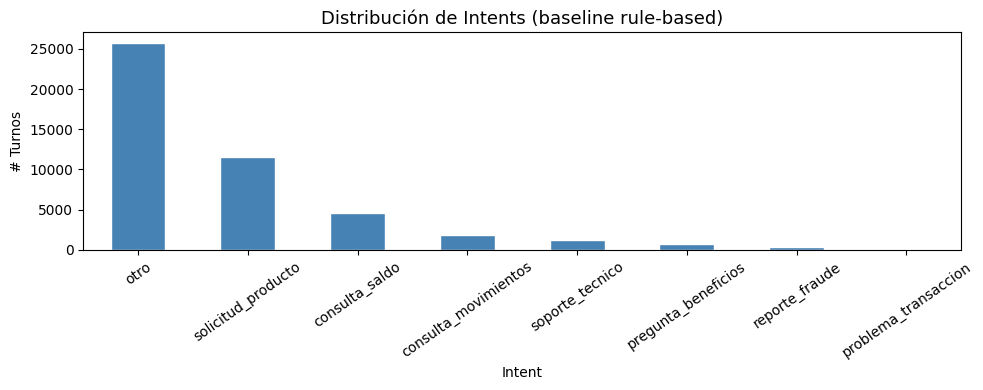

feat_intent_baseline
otro                    25761
solicitud_producto      11487
consulta_saldo           4638
consulta_movimientos     1792
soporte_tecnico          1275
pregunta_beneficios       787
reporte_fraude            350
problema_transaccion       46
Name: count, dtype: int64


In [19]:
# Distribución de intents
intent_dist = df_turns['feat_intent_baseline'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
intent_dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribución de Intents (baseline rule-based)', fontsize=13)
ax.set_xlabel('Intent')
ax.set_ylabel('# Turnos')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR.parent.parent / 'notebooks/uc4/uc4_fig_intent_dist.png', dpi=150)
plt.show()
print(intent_dist)

In [20]:
# Cross-signals summary
cross_cols = [
    'feat_cross_pregunta_post_rechazo',
    'feat_cross_fraude_y_atipico',
    'feat_cross_cashback_no_pro',
    'feat_cross_inversion_sin_producto',
]
cross_summary = pd.DataFrame({
    'cross_signal': cross_cols,
    'n_users':  [int(df_user_feats[c].sum()) for c in cross_cols],
    'pct_users': [f"{df_user_feats[c].mean()*100:.1f}%" for c in cross_cols],
})
print("\nCROSS-SIGNALS SUMMARY")
print(cross_summary.to_string(index=False))


CROSS-SIGNALS SUMMARY
                     cross_signal  n_users pct_users
 feat_cross_pregunta_post_rechazo        0      0.0%
      feat_cross_fraude_y_atipico       23      0.2%
       feat_cross_cashback_no_pro      188      1.3%
feat_cross_inversion_sin_producto      297      2.1%


In [21]:
# Null rates en features de usuario
numeric_cols = df_user_feats.select_dtypes(include=[np.number]).columns.tolist()
null_rates = df_user_feats[numeric_cols].isnull().mean().sort_values(ascending=False)
null_rates = null_rates[null_rates > 0]
if len(null_rates) > 0:
    print("\nCOLUMNAS CON NULOS (user-level):")
    print(null_rates)
else:
    print("\n✅ No hay nulos en features numéricas de usuario")


✅ No hay nulos en features numéricas de usuario


## 10. Persistencia final

Re-guardamos `feat_uc4_users.parquet` con los cross-signals incluidos y generamos el summary JSON.

In [22]:
import json

# Re-save users con cross-signals
df_user_feats.to_parquet(OUTPUT_DIR / "feat_uc4_users.parquet", index=False)
print(f"✅ feat_uc4_users.parquet (con crosses): {df_user_feats.shape}")

# Summary JSON
summary = {
    "intent_distribution": df_turns['feat_intent_baseline'].value_counts().to_dict(),
    "cross_signals": {
        "pregunta_post_rechazo":  int(df_user_feats['feat_cross_pregunta_post_rechazo'].sum()),
        "fraude_y_atipico":       int(df_user_feats['feat_cross_fraude_y_atipico'].sum()),
        "cashback_no_pro":        int(df_user_feats['feat_cross_cashback_no_pro'].sum()),
        "inversion_sin_producto": int(df_user_feats['feat_cross_inversion_sin_producto'].sum()),
    },
    "shapes": {
        "turns":      list(df_turns.shape),
        "convs":      list(df_conv_feats.shape),
        "users":      list(df_user_feats.drop(columns=['feat_conv_emb_user_pooling']).shape),
        "embeddings": list(embeddings.shape),
    }
}

with open(OUTPUT_DIR / "feat_uc4_cross_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("✅ All UC4 features persisted")
print(json.dumps(summary['cross_signals'], indent=2))

✅ feat_uc4_users.parquet (con crosses): (14095, 25)
✅ All UC4 features persisted
{
  "pregunta_post_rechazo": 0,
  "fraude_y_atipico": 23,
  "cashback_no_pro": 188,
  "inversion_sin_producto": 297
}
